In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
import os
import traceback

import matplotlib.pyplot as plt
import pandas as pd

from torch.utils.data import DataLoader

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [4]:
import generator_core as core
from aspect_red import *
from aspect_tetra import SolutionEvaluator

In [5]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [6]:
try:
    red = Red(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Red._prepare_language_model.cached


In [7]:
try:
    train_language_model = True
    print(red.language_model)
    print(red.get_language_model_parameter_count())
except:
    traceback.print_exc()

EncoderDecoderLSTM(
  (embedding): Embedding(16000, 512, padding_idx=0)
  (encoder_lstm): LSTM(512, 512, num_layers=2, batch_first=True)
  (decoder_lstm): LSTM(512, 512, num_layers=2, batch_first=True)
  (fc): Linear(in_features=512, out_features=16000, bias=True)
)
16612992


In [10]:
try:
    if train_language_model:
        red.language_model.trainer.device = 'cuda'
        red.language_model.trainer.epochs = 1

        for pg in red.language_model.trainer.optimizer.param_groups:
            # pg['lr'] = 0.0003
            print(pg['lr'])

        # red.language_model.embedding.weight.requires_grad = True
        print(red.language_model.embedding.weight.requires_grad)

        # red.language_model.dataloader = DataLoader(
        #     red.language_model.dataloader.dataset,
        #     batch_size=512,
        #     num_workers=2,
        #     collate_fn=collate_seq2seq,
        # )
        # red.language_model.trainer.train_dataloader = red.language_model.dataloader

        red.language_model.dataloader.dataset.seq_len = 512
        print(red.language_model.dataloader.dataset.seq_len)

except:
    traceback.print_exc()

0.0003
True
512


In [11]:
try:
    if train_language_model:
        red.language_model.train_model()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 2.65    TTS: 23.97    ETA: 936361.54
Epoch:  0/ 1    Train Loss: 2.64    TTS: 34.95    ETA: 682607.36
Epoch:  0/ 1    Train Loss: 2.59    TTS: 45.91    ETA: 597714.35
Epoch:  0/ 1    Train Loss: 2.55    TTS: 56.85    ETA: 555134.61
Epoch:  0/ 1    Train Loss: 2.84    TTS: 67.78    ETA: 529477.39
Epoch:  0/ 1    Train Loss: 2.97    TTS: 78.75    ETA: 512611.45
Epoch:  0/ 1    Train Loss: 3.23    TTS: 89.68    ETA: 500362.70
Epoch:  0/ 1    Train Loss: 2.88    TTS: 100.60    ETA: 491115.08
Epoch:  0/ 1    Train Loss: 2.47    TTS: 111.42    ETA: 483482.26
Epoch:  0/ 1    Train Loss: 2.44    TTS: 122.28    ETA: 477553.18
Epoch:  0/ 1    Train Loss: 2.52    TTS: 133.15    ETA: 472718.64
Epoch:  0/ 1    Train Loss: 2.33    TTS: 144.03    ETA: 468733.04
Epoch:  0/ 1    Train Loss: 2.19    TTS: 154.87    ETA: 465231.13
Epoch:  0/ 1    Train Loss: 2.22    TTS: 165.79    ETA: 462435.52
Epoch:  0/ 1    Train Loss: 2.30    TTS: 176.62    ETA: 459787.02
Epoch:  0/ 1    T

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_3600\2456067357.py", line 3, in <module>
    red.language_model.train_model()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_red\encoder_decoder.py", line 66, in train_model
    self.trainer.train()
    ~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 191, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 214, in _train_step
    for batch_data in self.train_dataloader:
                      ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 741, in __next__
    data = self._next_data()
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\utils\data\dataloade

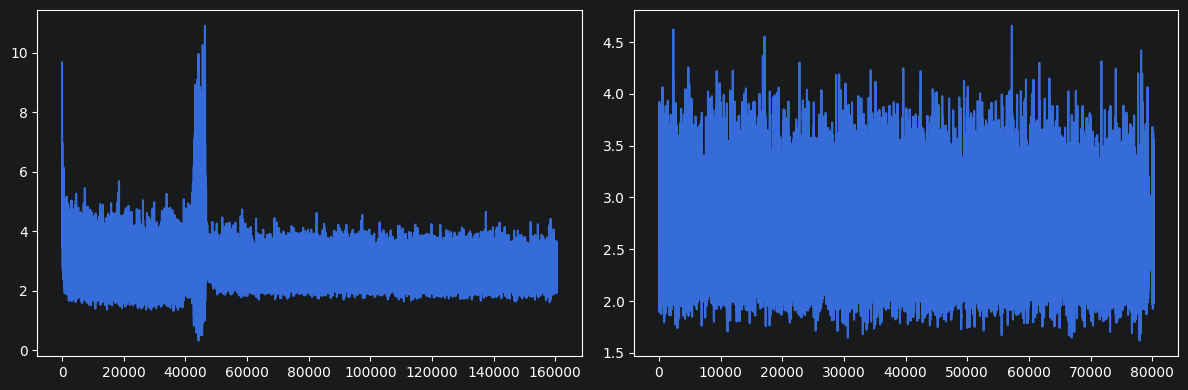

In [24]:
try:
    if train_language_model:
        loss = red.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.tight_layout(), plt.show()
except:
    traceback.print_exc()

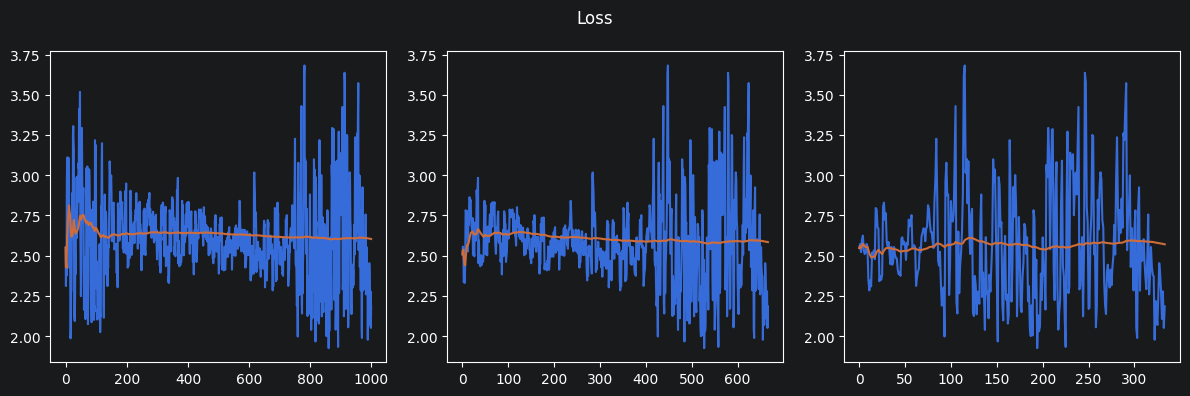

In [25]:
try:
    red.language_model.trainer.plot_loss(loss['train.batch'][-1000:])
except:
    traceback.print_exc()

In [26]:
try:
    if train_language_model:
        timers = red.language_model.trainer.timer.timers
        for key in timers: print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 1409.9510470000005
train_dataloader 0.003822448650198358
batch 0.08669464546949904


In [27]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Red._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: red.language_model, group='Red._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Creating Cache for Red._prepare_language_model.cached
Saved


In [22]:
try:
    print(red.inference('rock', 'black enter spell priests dragon', starting_words='', max_len=400))
except:
    traceback.print_exc()

go for the world
but it's hard for a love night's get one day , i'm falling with any night ( 1 )
( i love my life )
i'm ready for this time man 


In [17]:
try:
    _songs = red.bulk_inference(
        genres='pop',
        context_words="blinded city headlights life stockholm",
        max_len=500,
        temperature=1.0,
        top_k=50,
        n_songs=10,
    )
    for i, s in enumerate(_songs):
        print("SONG ", i + 1)
        print(s)
        print()
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


SONG  1
to go
if i ever find the world
i'll be in the morning ,
she's so ,
my dear , but it " s a bad
and i know you'd rather be mine
you love me
i just wanna see her in my mind
i will love you ?
all that makes this shit up and let her something you didn't have to , i know you make it better change
( why )
let " s just trying to see a bitch we're looking for the things i need is for me ?
yeah , how to fuck with me

i am alive
when you're gone
so long
he's like a life
i swear you really wanna be like this
she you are so far away don ( i know you )
to keep a fool
i " m not ready that
to last
it's all down
it ain't where the sun comes 
yeah [ x ]
i've the same
hey , i do
i'm feeling alone
i could break your ass on a backroad ( take it back now , no , no
but you go to my love what it feels like i am ?
<

SONG  2
, i'd still


now it's worth you
i " m gone

if you can " t tell 'cause the whole damn


is her'em and we can take you back , the people
'cause you can't see a couple
you don't kno

In [60]:
try:
    print(red.get_genre(1), red.get_context_words(1))
except:
    traceback.print_exc()

pop ['blinded', 'city', 'headlights', "you're", 'stockholm']


In [11]:
try:
    g, c, l = red.get_genre(1), " ".join(red.get_context_words(1)), red.get_lyrics(1)
    print(red.get_logits([(g, c, l)]).shape)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


torch.Size([1, 816, 16000])


In [29]:
try:
    evaluator = SolutionEvaluator(red)
except:
    traceback.print_exc()

In [33]:
try:
    bertscore = evaluator.compute_bertscore()
    print(bertscore)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6023.44it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'precision': np.float64(0.627433180809021), 'recall': np.float64(0.46006661653518677), 'f1': np.float64(0.5308709740638733)}


In [34]:
try:
    mauve = evaluator.compute_mauve()
    print(mauve)
except:
    traceback.print_exc()

Featurizing q: 100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


0.010100457455801053


In [35]:
try:
    perplexity = evaluator.compute_perplexity(collate=evaluator.default_collate)
    print(perplexity)
except:
    traceback.print_exc()

16.263698673248292


In [36]:
try:
    self_bleu = evaluator.compute_self_bleu()
    print(self_bleu)
except:
    traceback.print_exc()

0.06596044076439574


In [37]:
try:
    print("Bert Score:")
    print(f" * Precision : {bertscore['precision']:.3f}")
    print(f" * Recall    : {bertscore['recall']:.3f}")
    print(f" * F1 Measure: {bertscore['f1']:.3f}")
    print(f"Mauve Score  : {mauve:.3f}")
    print(f"Perplexity   : {perplexity:.3f}")
    print(f"Self BLUE    : {self_bleu:.3f}")
except:
    traceback.print_exc()

Bert Score:
 * Precision : 0.627
 * Recall    : 0.460
 * F1 Measure: 0.531
Mauve Score  : 0.010
Perplexity   : 16.264
Self BLUE    : 0.066
